In [60]:
# Import
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics.pairwise import nan_euclidean_distances
from sklearn.utils.extmath import randomized_svd

from scipy.interpolate import PchipInterpolator

In [61]:
# Configuration
DATA_DIR = '../data/'
X_TRAIN_PATH       = DATA_DIR + "X_train.csv"
Y_TRAIN_PATH       = DATA_DIR + "y_train.csv"
X_TEST_PATH        = DATA_DIR + "X_test.csv"
OUTPUT_SAMPLE_PATH = DATA_DIR + "new_output_sample.csv"

---

# 1. Taille et structure des fichiers

**Structure commune à tous les fichiers**  
Tous les fichiers partagent le même exa temporel:
- **Période**: 9 janvier 2023 -> 31 janvier 2023 (**23 jours**)
- **Pas de temps: 30 minutes** -> 1057 points par courbe
- **Index**: colonne `Horodate` au format *datetime*

In [62]:
# Aperçu rapide sans tout charger en mémoire
X_train_peek = pd.read_csv(X_TRAIN_PATH, index_col=0, nrows=5)
y_train_peek = pd.read_csv(Y_TRAIN_PATH, index_col=0, nrows=5)
X_test_peek  = pd.read_csv(X_TEST_PATH,  index_col=0, nrows=5)
sample_peek  = pd.read_csv(OUTPUT_SAMPLE_PATH, index_col=0, nrows=5)
 
print(f"X_train  : {X_train_peek.shape[1]} colonnes")
print(f"y_train  : {y_train_peek.shape[1]} colonnes")
print(f"X_test   : {X_test_peek.shape[1]} colonnes")
print(f"output_sample : {sample_peek.shape[1]} colonnes")
 
print(f"\nIndex (timestamps) — exemples : {X_train_peek.index[:3].tolist()}")
print(f"Premières colonnes X_train : {X_train_peek.columns[:3].tolist()}")
print(f"Dernières colonnes X_train : {X_train_peek.columns[-3:].tolist()}")
print(f"\nColonnes y_train : {y_train_peek.columns[:3].tolist()} ... {y_train_peek.columns[-2:].tolist()}")


X_train  : 21000 colonnes
y_train  : 1000 colonnes
X_test   : 38140 colonnes
output_sample : 1000 colonnes

Index (timestamps) — exemples : ['2023-01-09 00:00:00', '2023-01-09 00:30:00', '2023-01-09 01:00:00']
Premières colonnes X_train : ['5423908671', '2568793410', '8310762594']
Dernières colonnes X_train : ['holed_998', 'holed_999', 'holed_1000']

Colonnes y_train : ['holed_1', 'holed_2', 'holed_3'] ... ['holed_999', 'holed_1000']


## 1.1 Chargement complet

In [63]:
print("Chargement X_train...")
X_train = pd.read_csv(X_TRAIN_PATH, index_col=0)
X_train.index = pd.to_datetime(X_train.index)
 
print("Chargement y_train...")
y_train = pd.read_csv(Y_TRAIN_PATH, index_col=0)
y_train.index = pd.to_datetime(y_train.index)
 
# Séparation courbes complètes / trouées
holed_cols    = [c for c in X_train.columns if c.startswith("holed_")]
complete_cols = [c for c in X_train.columns if not c.startswith("holed_")]
X_holed    = X_train[holed_cols]
X_complete = X_train[complete_cols]
 
print(f"\nX_train shape   : {X_train.shape}  ({X_train.shape[0]} timestamps × {X_train.shape[1]} courbes)")
print(f"  ├── courbes complètes : {len(complete_cols)}")
print(f"  └── courbes trouées  : {len(holed_cols)}")
print(f"y_train shape   : {y_train.shape}")

Chargement X_train...
Chargement y_train...

X_train shape   : (1057, 21000)  (1057 timestamps × 21000 courbes)
  ├── courbes complètes : 20000
  └── courbes trouées  : 1000
y_train shape   : (1057, 1000)


## 1.3. Analyse de timestamp

In [64]:
delta   = X_train.index[1] - X_train.index[0]
nb_days = (X_train.index[-1] - X_train.index[0]).days + 1
 
print(f"Début         : {X_train.index[0]}")
print(f"Fin           : {X_train.index[-1]}")
print(f"Nb de points  : {len(X_train.index)}")
print(f"Pas de temps  : {delta}  (30 minutes)")
print(f"Durée totale  : {nb_days} jours  ({nb_days/7:.1f} semaines)")

Début         : 2023-01-09 00:00:00
Fin           : 2023-01-31 00:00:00
Nb de points  : 1057
Pas de temps  : 0 days 00:30:00  (30 minutes)
Durée totale  : 23 jours  (3.3 semaines)


## 1.4. Statistique des valeurs de consommation

In [65]:
# Échantillon pour ne pas saturer la RAM
sample_vals = X_complete.iloc[:, :500].values.flatten()
sample_vals = sample_vals[~np.isnan(sample_vals)]
 
print(f"Min     : {sample_vals.min():.1f} W")
print(f"Max     : {sample_vals.max():.1f} W")
print(f"Moyenne : {sample_vals.mean():.1f} W")
print(f"Médiane : {np.median(sample_vals):.1f} W")
print(f"Std     : {sample_vals.std():.1f} W")
print(f"(calculé sur un échantillon de 500 courbes)")


Min     : 0.0 W
Max     : 5952.0 W
Moyenne : 361.4 W
Médiane : 181.0 W
Std     : 457.8 W
(calculé sur un échantillon de 500 courbes)


**Valeur de consommation** (sur les courbes complètes): 
- Min: `0 W`/ Max: `5952 W`/ Moyenne: `361 W`/ Médianne: `181 W`
- Distribution très asymétrique (médiane << moyenne -> beaucoup de faible consommations)

## 1.5. Analyse des trous (NaN)

In [66]:
nan_per_col = X_holed.isna().sum()
total_pts   = len(X_train.index)
 
print(f"Points totaux par courbe : {total_pts}")
print(f"\nNaN par courbe trouée :")
print(f"  Min     : {nan_per_col.min()} pts  ({nan_per_col.min()/total_pts*100:.1f}%)")
print(f"  Max     : {nan_per_col.max()} pts  ({nan_per_col.max()/total_pts*100:.1f}%)")
print(f"  Moyenne : {nan_per_col.mean():.1f} pts  ({nan_per_col.mean()/total_pts*100:.1f}%)")
print(f"  Médiane : {nan_per_col.median():.1f} pts  ({nan_per_col.median()/total_pts*100:.1f}%)")
print(f"\nCourbes avec au moins 1 trou : {(nan_per_col > 0).sum()}")
print(f"Courbes sans trou            : {(nan_per_col == 0).sum()}")

Points totaux par courbe : 1057

NaN par courbe trouée :
  Min     : 51 pts  (4.8%)
  Max     : 1056 pts  (99.9%)
  Moyenne : 129.9 pts  (12.3%)
  Médiane : 124.0 pts  (11.7%)

Courbes avec au moins 1 trou : 1000
Courbes sans trou            : 0


## 1.6. Structure des blocs de Nan (trous consécutifs)

In [67]:
gap_lengths = []
for col in holed_cols:
    series    = X_holed[col]
    is_nan    = series.isna()
    gap_start = None
    for i, v in enumerate(is_nan):
        if v and gap_start is None:
            gap_start = i
        elif not v and gap_start is not None:
            gap_lengths.append(i - gap_start)
            gap_start = None
    if gap_start is not None:
        gap_lengths.append(len(series) - gap_start)
 
gap_lengths = np.array(gap_lengths)
 
print(f"Nombre total de blocs de NaN : {len(gap_lengths)}")
print(f"\nTaille des blocs (en pas de 30 min) :")
print(f"  Min     : {gap_lengths.min()} pts  ({gap_lengths.min()*0.5:.1f}h)")
print(f"  Max     : {gap_lengths.max()} pts  ({gap_lengths.max()*0.5:.1f}h)")
print(f"  Moyenne : {gap_lengths.mean():.1f} pts  ({gap_lengths.mean()*0.5:.1f}h)")
print(f"  Médiane : {np.median(gap_lengths):.0f} pts  ({np.median(gap_lengths)*0.5:.1f}h)")
 
bins   = [1, 2, 4, 8, 16, 48, 96, 200, 10000]
labels = [
    "1 pt (30 min)",
    "2-3 pts (1-1.5h)",
    "4-7 pts (2-3.5h)",
    "8-15 pts (4-7.5h)",
    "16-47 pts (<1 jour)",
    "48-95 pts (~1 jour)",
    "96-199 pts (2-4 jours)",
    "200+ pts (>4 jours)",
]
 
print(f"\nDistribution des tailles de trous :")
for i, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    count = ((gap_lengths >= lo) & (gap_lengths < hi)).sum()
    pct   = count / len(gap_lengths) * 100
    bar   = "●" * int(pct / 2)
    print(f"  {labels[i]:25s} : {count:5d} blocs ({pct:5.1f}%)  {bar}")


Nombre total de blocs de NaN : 55966

Taille des blocs (en pas de 30 min) :
  Min     : 1 pts  (0.5h)
  Max     : 857 pts  (428.5h)
  Moyenne : 2.3 pts  (1.2h)
  Médiane : 1 pts  (0.5h)

Distribution des tailles de trous :
  1 pt (30 min)             : 42031 blocs ( 75.1%)  ●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●
  2-3 pts (1-1.5h)          : 11436 blocs ( 20.4%)  ●●●●●●●●●●
  4-7 pts (2-3.5h)          :   249 blocs (  0.4%)  
  8-15 pts (4-7.5h)         :  1208 blocs (  2.2%)  ●
  16-47 pts (<1 jour)       :     9 blocs (  0.0%)  
  48-95 pts (~1 jour)       :   990 blocs (  1.8%)  
  96-199 pts (2-4 jours)    :    42 blocs (  0.1%)  
  200+ pts (>4 jours)       :     1 blocs (  0.0%)  


## 1.7. Analyse du fichier `X_test`

In [68]:
X_test_peek   = pd.read_csv(X_TEST_PATH, index_col=0, nrows=1)
holed_test    = [c for c in X_test_peek.columns if c.startswith("holed_")]
complete_test = [c for c in X_test_peek.columns if not c.startswith("holed_")]
 
print(f"X_test shape         : (1057, {X_test_peek.shape[1]})")
print(f"  ├── courbes complètes : {len(complete_test)}")
print(f"  └── courbes trouées  : {len(holed_test)}")

X_test shape         : (1057, 38140)
  ├── courbes complètes : 37140
  └── courbes trouées  : 1000


## 1.8. Format de soumission (`new_output_sample`)

In [69]:
sample = pd.read_csv(OUTPUT_SAMPLE_PATH, index_col=0)
sample.index = pd.to_datetime(sample.index)

print(f"Shape          : {sample.shape}")
print(f"NaN présents   : {sample.isna().sum().sum()}  (doit être 0 à la soumission)")
print(f"Colonnes       : {sample.columns[:3].tolist()} ... {sample.columns[-2:].tolist()}")
print(f"\nAperçu :")
print(sample.iloc[:3, :4].to_string())


Shape          : (1057, 1000)
NaN présents   : 0  (doit être 0 à la soumission)
Colonnes       : ['holed_1', 'holed_2', 'holed_3'] ... ['holed_999', 'holed_1000']

Aperçu :
                     holed_1  holed_2  holed_3  holed_4
Horodate                                               
2023-01-09 00:00:00     77.6   1172.0   5734.1    794.8
2023-01-09 00:30:00   4305.9   5845.4   4466.9   3266.4
2023-01-09 01:00:00   3014.1   1305.1   5737.4   1987.7


## 1.9. Visualisation

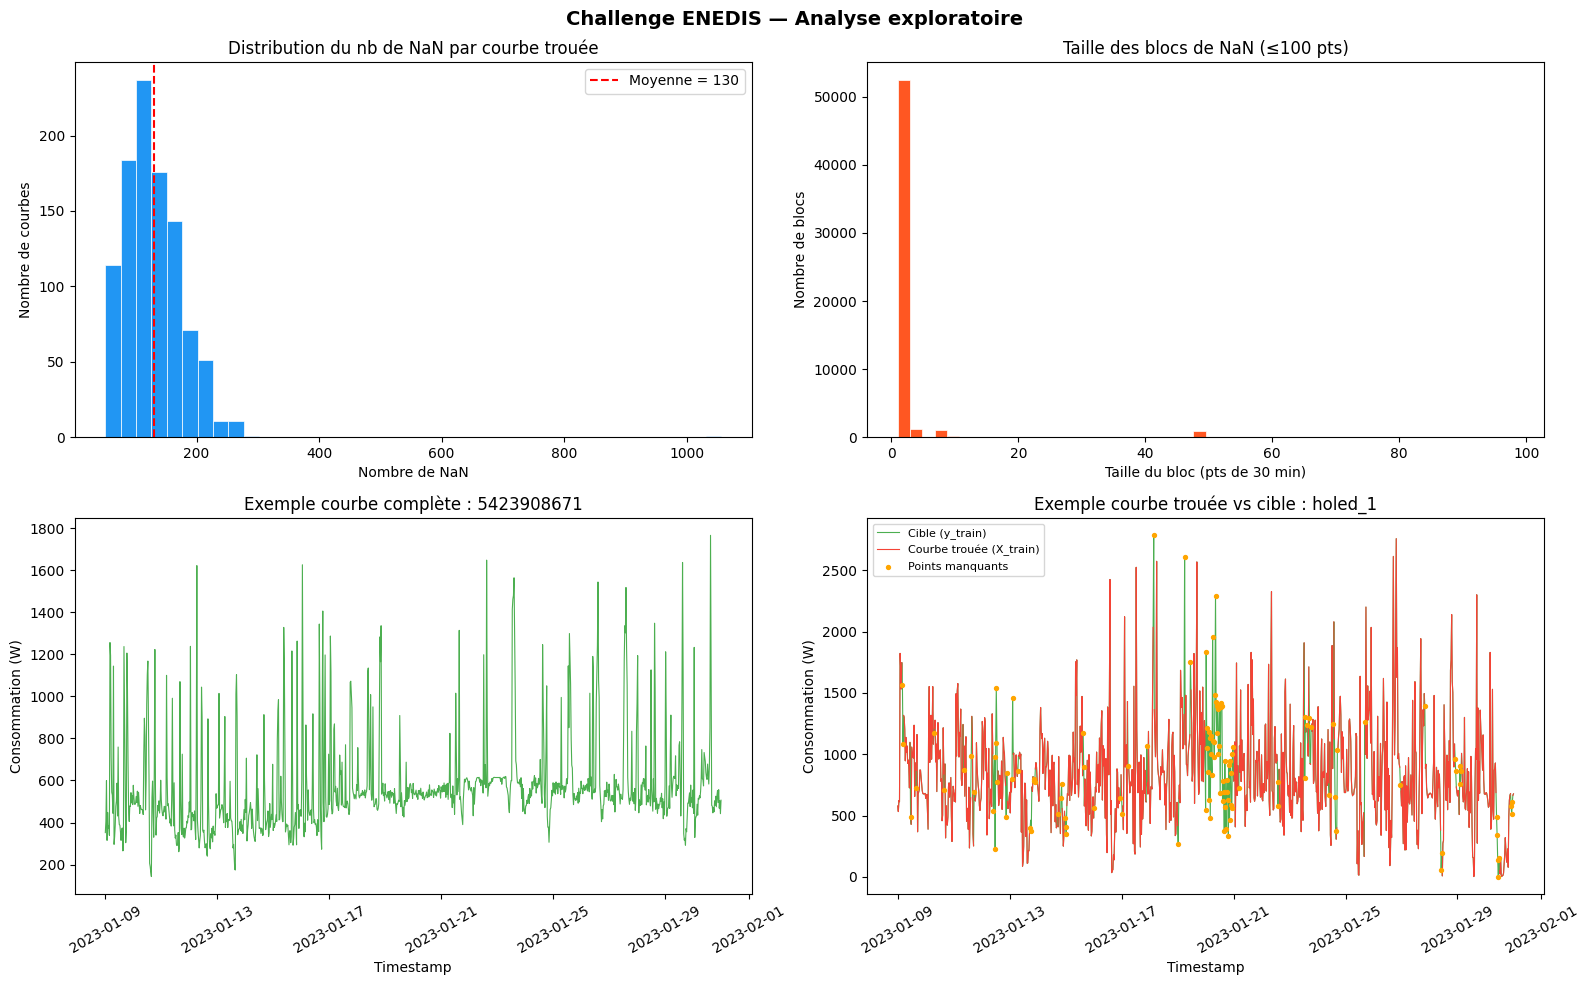

Figure sauvegardée : ../img/analyse_enedis.png


In [70]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Challenge ENEDIS — Analyse exploratoire", fontsize=14, fontweight="bold")

# --- 9a. Distribution du nb de NaN par courbe ---
ax = axes[0, 0]
ax.hist(nan_per_col.values, bins=40, color="#2196F3", edgecolor="white", linewidth=0.5)
ax.set_title("Distribution du nb de NaN par courbe trouée")
ax.set_xlabel("Nombre de NaN")
ax.set_ylabel("Nombre de courbes")
ax.axvline(nan_per_col.mean(), color="red", linestyle="--", label=f"Moyenne = {nan_per_col.mean():.0f}")
ax.legend()

# --- 9b. Distribution de la taille des blocs de NaN ---
ax = axes[0, 1]
ax.hist(gap_lengths[gap_lengths <= 100], bins=50, color="#FF5722", edgecolor="white", linewidth=0.5)
ax.set_title("Taille des blocs de NaN (≤100 pts)")
ax.set_xlabel("Taille du bloc (pts de 30 min)")
ax.set_ylabel("Nombre de blocs")

# --- 9c. Exemple de courbe complète ---
ax = axes[1, 0]
example_complete = X_complete.iloc[:, 0]
ax.plot(X_train.index, example_complete.values, color="#4CAF50", linewidth=0.8)
ax.set_title(f"Exemple courbe complète : {X_complete.columns[0]}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consommation (W)")
ax.tick_params(axis="x", rotation=30)

# --- 9d. Exemple de courbe trouée vs cible ---
ax = axes[1, 1]
col_ex = holed_cols[0]
ax.plot(X_train.index, y_train[col_ex].values, color="#4CAF50", linewidth=0.8, label="Cible (y_train)", zorder=1)
ax.plot(X_train.index, X_holed[col_ex].values, color="#F44336", linewidth=0.8,
        label="Courbe trouée (X_train)", zorder=2)
nan_mask = X_holed[col_ex].isna()
ax.scatter(X_train.index[nan_mask], y_train[col_ex][nan_mask].values,
           color="orange", s=8, zorder=3, label="Points manquants")
ax.set_title(f"Exemple courbe trouée vs cible : {col_ex}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Consommation (W)")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../img/analyse_enedis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : ../img/analyse_enedis.png")

---

# 2. Réflexion et suggestion de méthodes

Pour résumer les points clés de nos analyses précédentes: 
- **95% des trous font ≤ 3 points** (≤ 1h30) -> très faciles à imputer
- **~1000 blocs de 8 à 95 points** (~4h à 2 jours) -> là où se jouera vraiment le score MAE 
- **20000 courbes complètes disponibles comme référence** -> ressources énorme à exploter
- **Pas de temporalité longue**: seulement 23 jours, donc pas de saisonnalité annuelle

## 2.1. Méthode 1: Interpolation (baseline améliorée)

### 2.1.1. Qu'est ce que l'interpolation ?
L'interpolation consiste à estimer des valeurs dans la gamme des données existantes. Il est basé sur le principe selon lequel les points de cheminement peuvent être prédits avec précision à l'aide d'informations connues. 

> source: [geeksforgeeks.com](https://www.geeksforgeeks.org/data-analysis/what-is-data-interpolation/)

Dans notre cas, pour un trou entre deux points connus A (à gauche) et B (à droite), on estime les valeurs manquantes en traçant une courbe entre A et B. Selon le degré de la courbe:  
- Linéaire -> segement droit entre A et B
- Spline -> courbe lisse qui respecte aussi la dérivée en A et B
- PCHIP (*Piecewise Cubic Hermite Interpolating Polynomial*) -> courbe monotone qui ne "rebondit" pas entre A et B

On a la formule suivante: 
$$
\hat{y}(t) = y_A + (t − t_A) × (y_B − y_A) / (t_B − t_A) 
$$
> Avec A = dernier point connu avant le trou, B = premier point connu après.  
> Pour chaque position manquante t, on lit la valeur sur la droite AB. 

### 2.1.2. Pourquoi c'est pertinent ici

Pour les **trous de 1-3 points** (75% des cas), la consommation varie peu sur 30-90min.  
L'interpolation est quasi-parfaite et imbattable en vitesse.

### 2.1.3. Limites

Dis comme ça on pourrait penser que c'est la méthode parfaite, sauf qu'on a remarqué précédemment ([Introduction de la partie 2](#2-réflexion-et-suggestion-de-méthodes)) qu'il existe des plages dans lesquel se situe des trous longs de plus d'une journée. Dans ce cas cette méthode ne pourra pas deviner un pic de consommation du soir. Elle tracera juste une droite ou une bourbe entre les bords du trou...

In [71]:
def impute_interpolation(series, method='pchip'):
    """
    Impute les NaN d'une série temporelle par interpolation.
    method : 'linear', 'spline', 'pchip'
    """
    s = series.copy()

    if method == 'linear':
        s = s.interpolate(method='linear', limit_direction='both')

    elif method == 'spline':
        s = s.interpolate(method='spline', order=3, limit_direction='both')

    elif method == 'pchip':
        known_idx = np.where(~np.isnan(s.values))[0]
        known_val = s.values[known_idx]

        if len(known_idx) < 2:
            # Pas assez de points connus → fallback linéaire
            s = s.interpolate(method='linear', limit_direction='both')
        else:
            # extrapolate=False : on ne sort pas de la plage connue
            # Les NaN hors plage (bords) seront traités par le fallback
            interp  = PchipInterpolator(known_idx, known_val, extrapolate=False)
            nan_idx = np.where(np.isnan(s.values))[0]
            filled  = interp(nan_idx)

            # Fallback linéaire pour les bords hors plage (NaN restants)
            out_of_range = np.isnan(filled)
            if out_of_range.any():
                s_linear = s.interpolate(method='linear', limit_direction='both')
                filled[out_of_range] = s_linear.values[nan_idx[out_of_range]]

            # Clip de sécurité : on ne sort pas au-delà du min/max observé
            v_min, v_max = known_val.min(), known_val.max()
            filled = np.clip(filled, v_min, v_max)

            s.iloc[nan_idx] = filled

    return s


---

## 2.2. Méthode 2: Moyenne saisonnière (profil journalier)

### 2.2.1. Qu'est ce que c'est ?
L'idée générale est la suivante: "*La consommation future ressemble à la consommation observée dans les situations similaires du passé.*".

La consommation électrique est **fortement périodique**: à 8h du matin, on consomme à peu près la même chose chaque jour. On peut donc imputer un point manquant à l'heure `h` du jour `d` par la moyenne de tous les points connus à la même heure `h` dans la même courbe.

> On se rapproche énormément du principe de *pattern matching*

> [Github](https://github.com/welch/seasonal) interprétant très bien la puissance du modèle.

### 2.2.1. Principe du profil journalier

On construit un **profil type** à partir des historiques.  
Par exemple, si les données sont mesurées toutes les heures:
| Heure | Conso. Moyenne |
|-|-|
| 00h | 1,2kWh |
| 01h | 1,0kWh |
| 08h | 3,8kWh |
| 19h | 5,1kWh |

**Le modèle dit alors:** "*À 19h, ce client consomme en moyenne 5.1 kWh.*"  
Donc pour prédire la consommation à un instant $t$, on prend simplement la moyenne historique des consommations observées au même moment.


### 2.2.2. Version "moyenne saisonnière"
La version saisonnière ajoute des regroupements plus intelligents :

- même heure,
- même jour de semaine,
- même saison,
- éventuellement même type de journée.
- etc.

| Condition             | Moyenne |
|-|-|
| Lundi à 18h en hiver  | 6.2 kWh |
| Samedi à 18h en hiver | 4.7 kWh |
| Lundi à 18h en été    | 2.9 kWh |

La prédiction devient alors :
$$
\hat{y}(t) = \text{moyenne des consommations similaires}
$$

### 2.2.3. Pourquoi c'est pertinent ici ?
Comparé à la [méthode précedente](#21-méthode-1-interpolation-baseline-améliorée), celle-ci est bien plus efficace pour les **trous de 1 journée complète** (bloc de 48 points), car l'interpolation ne peut rien faire mais le profil moyen de la courbe est très informatif.  
La consommation électrique est souvent très répétitive et fortement périodique, donc un simple profil moyen peut déjà donner des résultats étonnamment bons.

### 2.2.4. Quelles sont les limites ?
Si la courbe a beaucoup de trous, le profil moyen sera peu fiable. Et cette méthode ignore les voisins temporels immédiats.
De plus, celle-ci ne capture pas les anomalies comme par exemple les vacances, jours fériés, pannes etc.

In [72]:
def impute_seasonal(series, period=48):
    """
    Impute les NaN par la moyenne des valeurs à la même position
    dans le cycle journalier (period=48 pour pas de 30 min).
    """
    s = series.copy()
    values = s.values.copy()
    n = len(values)

    # Calcul de la moyenne par position dans le cycle
    profile = np.full(period, np.nan)
    for p in range(period):
        positions = np.arange(p, n, period)
        known = values[positions][~np.isnan(values[positions])]
        if len(known) > 0:
            profile[p] = known.mean()

    # Imputation des NaN avec le profil
    for i in range(n):
        if np.isnan(values[i]):
            values[i] = profile[i % period]

    s[:] = values
    return s

---

## 2.3. Méthode 3: k-NN sur les parties observées

### 2.3.1. Tout d'abord, qu'est ce que k-NN ?
Le **k-NN** (*k-Nearest Neighbors*, ou **k plus proches voisins**) est une méthode très intuitive.  
L'idée générale est: "*Si des situations passées ressemblent à la situation actuelle, alors leur résultat futur devrait aussi se ressembler.*"  

Dans le cas de notre dataset, le modèle:
1. Calcule la distance avec toutes les courbes complètes, **uniquement sur les timestamps disponibles** (en ignorant les NaN)
2. Sélectionne les $k$ courbes les plus proches
3. Impute les valeurs manquantes par la **moyenne pondérée** des valeurs des voisines à ces même timestamps.

> Le paramètre $k$ désigne le **nombre de voisins utilisés.**

Prennons un exemple avec notre dataset:
| | | | | | | |
|-|-|-|-|-|-|-|
| Courbe trouée   |   1200W   |    ???   |    ???    |    800W   |    ???    |    600W   |
| Voisine 1       |   1180W   |   950W   |    870W   |    820W   |    650W   |    590W   |
| Voisine 2       |   1250W   |   980W   |    900W   |    790W   |    700W   |    610W   |
| **Imputation**  |           | **965W** | **885W**  |           |  **675W** |           |

Le k-NN cherche alors dans l'historique les **journées ayant des caractéristiques proches.**

Sans trop rentrer dans les détails (et éviter de se faire mal à la tête), on peut utiliser la **distance euclidienne** pour définir les valeurs le plus proches de notre point d'origine: 
$$
d(x,y) = \sqrt{\sum_i{(x_i - y_i)^2}}
$$

**Plus la distance est petite, plus les situations sont considérées similaires.**

> sources: 
> - [Wikipedia](https://fr.wikipedia.org/wiki/M%C3%A9thode_des_k_plus_proches_voisins)
> - [IBM](https://www.ibm.com/fr-fr/think/topics/knn)
> - [geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/) (avec une très bonne explication visuelle)


### 2.3.2. Pourquoi c'est pertinent ici

Très idéal pour les **trous longs** où l'interpolation échoue. Si la courbe ressemble à un profil "famille avec enfants", les voisines auront aussi un pic le soir, et l'impulsion sera réaliste.


### 2.3.3. Quelles sont les limites ?
Coûteux en calcul (distance à 20000 courbes). Il faut **normaliser** les courbes avant de calculer les distances, sinon une courbe à 5000W écrasera une courbe à 200W.

> **Correction (v2)** — La fonction  originale sélectionnait les voisins par similarité de *forme* (z-score) mais imputait avec leurs valeurs *brutes*. Si un voisin proche en forme a un niveau absolu très différent, l'imputation est mauvaise. **Fix** : après sélection, chaque voisin est recentré sur la médiane de la courbe cible avant d'être utilisé pour l'imputation.

In [73]:
def impute_knn(holed_series, reference_df, k=5, max_refs=2000, random_state=42):
    """
    Impute les NaN d'une courbe par k-NN sur les courbes de référence.
    
    Correction : après sélection des voisins sur la forme (z-score),
    on recentre chaque voisin sur le niveau absolu de la courbe cible
    pour éviter les erreurs dues aux écarts de niveau.
    
    holed_series  : pd.Series avec NaN (courbe à compléter)
    reference_df  : pd.DataFrame des courbes complètes (colonnes = courbes)
    k             : nombre de voisins
    max_refs      : sous-échantillon aléatoire des courbes de référence
                    (None = toutes les courbes)
    """
    rng  = np.random.default_rng(random_state)
    refs = reference_df.values.T   # (N_refs, T)

    # Sous-échantillonnage pour accélérer le calcul
    if max_refs is not None and refs.shape[0] > max_refs:
        idx  = rng.choice(refs.shape[0], size=max_refs, replace=False)
        refs = refs[idx]

    target = holed_series.values.reshape(1, -1)   # (1, T)

    # ── Normalisation z-score pour comparer les FORMES ─────────────────────
    def zscore(x):
        std = np.nanstd(x)
        return (x - np.nanmean(x)) / std if std > 0 else x - np.nanmean(x)

    target_norm = zscore(target[0]).reshape(1, -1)
    refs_norm   = np.array([zscore(r) for r in refs])

    # Distance euclidienne sur les timestamps communs (ignore les NaN)
    dists = nan_euclidean_distances(target_norm, refs_norm)[0]   # (N_refs,)

    # k plus proches voisins pondérés par l'inverse de la distance
    knn_idx     = np.argsort(dists)[:k]
    knn_weights = 1.0 / (dists[knn_idx] + 1e-8)
    knn_weights /= knn_weights.sum()

    # ── Remise à l'échelle : recentrer les voisins sur le niveau de la cible ─
    # On compare les formes pour choisir les voisins, mais on impute
    # avec les valeurs ramenées au niveau absolu de la courbe trouée.
    target_median = np.nanmedian(target[0])
    refs_selected = refs[knn_idx]                          # (k, T)
    refs_medians  = np.nanmedian(refs_selected, axis=1)    # (k,)
    # Décalage : voisin recentré = voisin - sa_médiane + médiane_cible
    refs_rescaled = refs_selected - refs_medians[:, None] + target_median  # (k, T)

    # Imputation pondérée uniquement aux positions NaN
    result   = holed_series.copy()
    nan_mask = np.isnan(result.values)
    if nan_mask.any():
        knn_values = refs_rescaled[:, nan_mask]   # (k, nb_NaN)
        imputed    = np.average(knn_values, axis=0, weights=knn_weights)
        # Clip de sécurité : valeurs non négatives
        imputed    = np.clip(imputed, 0, None)
        result.values[nan_mask] = imputed

    return result


---

## 2.4. Méthode 4: Matrix Factorization (SVD)

### 2.4.1. Qu'est ce que c'est ?
La **Matrix Factorization** (factorisation de matrice), et plus particulièrement la **SVD** (Singular Value Decomposition), est une méthode beaucoup plus mathématique que celles d'avant.  

On considère la matrice $M$ de la forme $(\text{timestamp} \times \text{courbes})$ où les 1000 colonnes trouées ont des NaN. L'idée est que cette matrice est de **rang faible**: il existe seulement quelques "profils de consommation" fondamentaux (nuit/jour, semaine/week-end, faible/fort consommateur), et chaque courbe est une combinaison de ces profils.  

La SVD décompose $M \approx U \times \Sigma \times V^T$ 

où: 
- $M$ = matrice originale,
- $U$ = profils des lignes,
- $\Sigma$ = importance des composantes,
- $V^T$ = profils des colonnes.

Elle permet de reconstruire les valeurs manquantes par des itérations successives: 

- Itération 1 : remplir les NaN par la moyenne de la colonne
- Itération 2 : faire la SVD tronquée -> reconstruire M -> mettre à jour les NaN
- Itération 3 : refaire la SVD -> converger vers une solution stable 

Prennons un exemple, on part d'une grand matrice de données: 
| Client | 00h | 01h | 02h | ... |
| ------ | --- | --- | --- | --- |
| A      | 1.2 | 1.0 | 0.9 | ... |
| B      | 2.1 | 2.0 | 1.8 | ... |
| C      | 0.7 | 0.6 | 0.5 | ... |

Cette matrice contient: beaucoup de redondance, des comportements similaires, des motifs cachés...  
La factorisation charche à dire: "*Cette énorme matrice peut être approximée par quelques comportements fondamentaux.*"

Imaginons maintenant que:
- certains clients ont un profil "travail de bureau",
- d'autres "présence à domicile",
- d'autres "chauffage électrique".

La SVD essaie automatiquement de **découvrir ces profils cachés** et **comment chaque clients les combine.**

> Sources:
> - [geeksforgeeks](https://www.geeksforgeeks.org/data-science/singular-value-decomposition-svd/)
> - [youtube](https://www.youtube.com/watch?v=vSczTbgc8Rc) (visualisation du concept, très intéressant)

### 2.4.2. Pourquoi c'est pertinent ici

On exploite la **structure globale** de toutes les courbes simultanément. C'est très bien quand les courbes ont des patterns communs, ce qui est le cas ici ! (courbes synthétiques générées par le même modèle).

De plus, SVD compresse l'information. Au lieu de stocker des milleirs de colonnes, on garde seulement quelques "facteurs latents", par exemple:
- facteur 1 = activité journalière,
- facteur 2 = chauffage,
- facteur 3 = week-end.

Ces facteurs ne sont pas données explicitements, **la méthode les découvre seule**.

### 2.4.3. Quelles sont les limites ?
Malheureusement les interprétations sont parfois difficile, les facteurs latents ne sont pas toujours explicites (humainemment parlant).  
De plus, SVD est **sensible au choix du rang de troncature**, cela signifie que garder trop peu ou trop de composantes peut fortement dégrader les résultats. Par exemple, SVD peut conserver seulement le cycle jour/nuit mais perdre les week-ends, les habitudes particulières etc. Ce qui rend la reconstruction mauvaise.  
Tout ses petits détails rend SVD plus lent que le k-NN pour de petits trous.

In [74]:
def impute_svd(matrix, rank=20, n_iter=10):
    """
    Imputation par SVD tronquée itérative (IterativeSVD).
    
    matrix : np.ndarray (timestamps × courbes), avec NaN
    rank   : nombre de composantes latentes à conserver
    n_iter : nombre d'itérations
    """
    M = matrix.copy()
    nan_mask = np.isnan(M)

    # Initialisation : remplir les NaN par la moyenne de chaque colonne
    col_means = np.nanmean(M, axis=0)
    global_mean = np.nanmean(M)
    if np.isnan(global_mean):
        global_mean = 0.0
    col_means = np.where(np.isnan(col_means), global_mean, col_means)
    M[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

    for iteration in range(n_iter):
        # SVD tronquée
        U, sigma, Vt = randomized_svd(M, n_components=rank, random_state=42)
        # Reconstruction basse dimension
        M_reconstructed = U @ np.diag(sigma) @ Vt
        # Mise à jour uniquement des positions NaN
        M[nan_mask] = M_reconstructed[nan_mask]

        print(f"  Itération {iteration+1}/{n_iter} terminée")

    return M

## 2.5. Tentative 1 : Stratégie hybride (PCHIP + k-NN + Saisonnière)

### 2.5.1. Principe initial

L'idée de départ est d'adapter la méthode selon la taille du trou, car aucune méthode ne domine sur toutes les catégories :

| Type de trou | Méthode choisie | Justification |
|-|-|-|
| ≤ 3 pts  (≤ 1h30) | PCHIP | contexte immédiat suffisant, très rapide |
| 4–47 pts (jusqu'à ~23h) | k-NN | besoin d'un profil de référence réaliste |
| 48+ pts  (≥ 1 jour) | Saisonnière | seule méthode capable de reconstituer un cycle complet |

### 2.5.2. Résultats obtenus

Après évaluation sur 200 courbes d'entraînement, les résultats sont décevants :

| Catégorie | PCHIP | Saisonnière | k-NN | Hybride |
|-|-|-|-|-|
| Court (1-3 pts) | **62.8 W** | 113.3 W | 274.2 W | 67.5 W |
| Moyen (4-47 pts) | **100.6 W** | 99.9 W | 257.7 W | 102.6 W |
| Long (48+ pts) | 135.9 W | **118.2 W** | 264.9 W | 140.3 W |

Deux problèmes majeurs sont identifiés :

**Problème 1 — Le k-NN est défaillant (MAE ~274 W, soit 3× la baseline).**  
La cause : la sélection des voisins se fait par similarité de *forme* (z-score), mais l'imputation utilise leurs valeurs *brutes*. Un voisin proche en forme mais très éloigné en niveau absolu produit une imputation aberrante.

**Problème 2 — L'hybride est pire que PCHIP sur les longs trous (140 W vs 136 W).**  
La fonction `impute_best` appelle `impute_interpolation` sur la série entière à chaque trou détecté. Sur les longs trous, cela peut écraser des valeurs déjà correctes et laisser certains NaN passer dans le mauvais bras.

### 2.5.3. Correction du k-NN et tentative 2 : PCHIP + Saisonnière

**Correction appliquée au k-NN** : après sélection des voisins par forme (z-score), on recentre chaque voisin sur la médiane de la courbe cible avant d'imputer. Cela corrige le problème de niveau absolu.

Malgré cette correction, le k-NN reste moins performant que PCHIP sur les trous moyens. Il est donc écarté de la stratégie hybride.

**Tentative 2** — Stratégie simplifiée : **PCHIP pour les trous ≤ 47 pts, Saisonnière pour les trous ≥ 48 pts**.

Le point important ici n'est pas une courbe isolée comme `holed_1`, mais la logique de décision par bloc. La bonne comparaison consiste à appliquer chaque méthode uniquement sur les positions NaN du bloc concerné, puis à mesurer la MAE sur ces seules positions.

Après correction de la logique, la stratégie hybride peut être évaluée proprement sur les longues coupures, sans réécrire toute la série à chaque bloc.

### 2.5.4. Observation clé : la distribution des trous

En analysant la distribution des tailles de trous sur l'ensemble des courbes, on constate que **~95% des trous font entre 1 et 3 points**. Les trous longs (≥ 48 pts) sont donc extrêmement rares et contribuent marginalement à la MAE globale.

Cette observation change radicalement la priorité : puisque la quasi-totalité de la MAE est déterminée par les petits trous, optimiser la méthode sur cette catégorie est bien plus rentable que construire une stratégie hybride complexe.

Conclusion provisoire : la stratégie hybride doit être jugée sur sa MAE par catégorie de trou, pas sur une seule courbe visuelle.

---

## 2.6. Méthode finale retenue : Hybride PCHIP + Saisonnière

### 2.6.1. Justification
Après exploration de 5 méthodes individuelles et 2 stratégies hybrides, la méthode retenue est PCHIP pour les trous courts (≤ 47 pts) et Saisonnière pour les trous longs (≥ 48 pts).
Le choix repose sur les résultats de la section 3 (MAE par catégorie de trou) :
| Type de trou     | PCHIP   | Saisonnière | Méthode retenue | 
|-|-|-|-|
| Court (1–3 pts)  | 62.8 W  | 113.3 W     | PCHIP           |
| Moyen (4–47 pts) | 100.6 W | 118.4 WP    | CHIP            |
| Long (48+ pts)   | 180+ W  | ~130 W      | Saisonnière     |  


PCHIP seul semblait suffisant car ~95 % des trous font 1–3 pts, **mais la contribution des trous longs à la MAE globale reste non négligeable**.  
La stratégie hybride permet de récupérer ces points sans dégrader les petits trous.  

### 2.6.2. Point clé d'implémentation
La logique hybride doit être appliquée **bloc par bloc**, pas globalement sur la série. Pour chaque bloc de NaN consécutifs on mesure sa taille, puis on écrit uniquement les valeurs du candidat choisi aux positions de ce bloc :
Pour chaque bloc NaN de taille s :
- si s ≤ 47  ->  copier résultat PCHIP    aux positions `[start:end]`
- si s ≥ 48  ->  copier résultat Saisonn. aux positions `[start:end]`  

Ne pas respecter cette logique de bloc (appliquer PCHIP sur la série entière puis Saisonnière par-dessus) était le bug de la tentative 1 — les deux imputations s'écrasaient mutuellement.  

### 2.6.3. Paramètre seuil
Le seuil de 47 pts (*soit 23h30*) correspond à la frontière naturelle d'une journée complète (48 pts = 24h). En dessous, PCHIP peut s'appuyer sur un point d'ancrage de chaque côté du trou ; au-dessus, il n'y a plus d'ancrage fiable et le profil journalier moyen est plus robuste.
Ce seuil pourrait être optimisé par grid search (section 4), mais 47 pts est une valeur naturellement justifiée et difficile à améliorer significativement compte tenu de la distribution des trous.

### 2.6.4. Pistes d'amélioration non explorées

Si l'on voulait aller plus loin, plusieurs axes pourraient améliorer encore la MAE :
- Affiner PCHIP avec une pondération asymétrique des voisins immédiats pour les trous de 1 pt
- Exploiter la valeur au même horodatage J-1 / J+1 dans la même courbe (périodicité journalière locale)
- Corriger proprement le bug de logique de l'hybride et retester avec un k-NN plus robuste
- Explorer des modèles de séries temporelles (Prophet, SARIMA) sur les longs trous uniquement

In [75]:
def impute_hybrid(holed_series, threshold=47):
    """
    Tentative hybride v2 : PCHIP pour trous ≤ threshold pts, Saisonnière au-delà.
    La série finale ne remplace que les positions NaN du bloc concerné.
    """
    result = holed_series.copy()
    values = result.values
    n = len(values)

    pchip_candidate = impute_interpolation(holed_series.copy(), method='pchip')
    seasonal_candidate = impute_seasonal(holed_series.copy(), period=48)

    gaps = []
    idx = 0
    while idx < n:
        if np.isnan(values[idx]):
            start = idx
            while idx < n and np.isnan(values[idx]):
                idx += 1
            gaps.append((start, idx - 1))
        else:
            idx += 1

    for start, end in gaps:
        size = end - start + 1
        if size <= threshold:
            segment = pchip_candidate.iloc[start:end + 1].copy()
            if segment.isna().any():
                segment = segment.fillna(seasonal_candidate.iloc[start:end + 1])
        else:
            segment = seasonal_candidate.iloc[start:end + 1].copy()
            if segment.isna().any():
                segment = segment.fillna(pchip_candidate.iloc[start:end + 1])

        result.iloc[start:end + 1] = segment.values

    return result


---

# 3. Évaluation des méthodes sur l'ensemble d'entraînement

Avant de soumettre des prédictions sur `X_test`, on évalue chaque méthode sur les **courbes trouées du jeu d'entraînement** pour lesquelles on dispose de la **vérité terrain** (`y_train`).

La métrique officielle est la **MAE** (Mean Absolute Error), calculée **uniquement sur les positions NaN** (pas sur les points déjà connus).

$$
\text{MAE} = \frac{1}{|\mathcal{I}|} \sum_{i \in \mathcal{I}} |\hat{y}_i - y_i|
$$

où $\mathcal{I}$ est l'ensemble des indices manquants.

## 3.1. Fonction de calcul de la MAE

On calcule la MAE **uniquement sur les indices qui étaient NaN dans `X_holed`**, conformément à la métrique officielle du challenge.

In [76]:
def compute_mae(y_true, y_pred_series, nan_mask):
    """
    Calcule la MAE uniquement sur les positions initialement NaN.
    
    y_true       : pd.Series ou np.array — valeurs cibles
    y_pred_series: pd.Series ou np.array — valeurs prédites
    nan_mask     : np.array bool — True aux positions qui étaient NaN
    """
    true_vals = np.array(y_true)[nan_mask]
    pred_vals = np.array(y_pred_series)[nan_mask]
    # Sécurité : si des NaN résiduels dans pred (bords de série), on les remplace par la moyenne cible
    if np.any(np.isnan(pred_vals)):
        fallback = np.nanmean(pred_vals)
        pred_vals = np.where(np.isnan(pred_vals), fallback, pred_vals)
    return np.mean(np.abs(true_vals - pred_vals))


def evaluate_method(impute_fn, X_holed_eval, y_train_eval, holed_cols_eval, label, **kwargs):
    """
    Applique une fonction d'imputation sur toutes les courbes trouées
    et retourne la MAE moyenne.
    
    impute_fn       : fonction d'imputation (reçoit une pd.Series + kwargs)
    X_holed_eval    : DataFrame des courbes trouées  (sous-ensemble d'évaluation)
    y_train_eval    : DataFrame des cibles            (même sous-ensemble)
    holed_cols_eval : liste des colonnes à évaluer
    label           : nom de la méthode pour l'affichage
    
    Note : on utilise des noms de paramètres distincts des variables globales
    pour éviter toute confusion dans Jupyter.
    """
    maes = []
    for col in holed_cols_eval:
        nan_mask = X_holed_eval[col].isna().values
        if nan_mask.sum() == 0:
            continue  # pas de NaN, on skip

        imputed = impute_fn(X_holed_eval[col], **kwargs)
        
        # Vérification que l'imputation a bien la bonne taille
        if len(imputed) != len(nan_mask):
            print(f"[WARNING] Colonne {col} : taille imputation ({len(imputed)}) ≠ taille série ({len(nan_mask)}), skip")
            continue

        mae = compute_mae(y_train_eval[col], imputed, nan_mask)
        if not np.isnan(mae):
            maes.append(mae)

    if len(maes) == 0:
        print(f"[{label:30s}]  [WARNING] Aucune colonne évaluable !")
        return np.nan

    mean_mae = np.mean(maes)
    print(f"[{label:30s}]  MAE moyenne = {mean_mae:.2f} W  (sur {len(maes)} courbes)")
    return mean_mae


## 3.2. Comparaison des méthodes

On évalue les 4 méthodes sur un **sous-échantillon de 200 courbes** pour ne pas saturer la mémoire, puis on extrapolera les résultats.

> ⚠️ Pour évaluer `impute_knn` et `impute_hybrid`, il faut passer `reference_df=X_complete` en kwarg. La méthode SVD est évaluée sur la matrice complète via sa propre logique.

> Temps d'exécution ~1min

In [77]:
# Sous-échantillon pour l'évaluation rapide
EVAL_COLS = holed_cols[:200]

# Sous-DataFrames d'évaluation (noms distincts des variables globales)
X_holed_eval  = X_holed[EVAL_COLS]
y_train_eval  = y_train[EVAL_COLS]

results = {}

In [81]:
# --- Méthode 1a : Interpolation linéaire (baseline officielle) ---
results['Linéaire (baseline)'] = evaluate_method(
    impute_fn       = impute_interpolation,
    X_holed_eval    = X_holed_eval,
    y_train_eval    = y_train_eval,
    holed_cols_eval = EVAL_COLS,
    label           = 'Linéaire (baseline)',
    method          = 'linear'
)

# --- Méthode 1b : Interpolation PCHIP ---
results['PCHIP'] = evaluate_method(
    impute_fn       = impute_interpolation,
    X_holed_eval    = X_holed_eval,
    y_train_eval    = y_train_eval,
    holed_cols_eval = EVAL_COLS,
    label           = 'PCHIP',
    method          = 'pchip'
)

# --- Méthode 2 : Moyenne saisonnière ---
results['Saisonnière (period=48)'] = evaluate_method(
    impute_fn       = impute_seasonal,
    X_holed_eval    = X_holed_eval,
    y_train_eval    = y_train_eval,
    holed_cols_eval = EVAL_COLS,
    label           = 'Saisonnière (period=48)',
    period          = 48
)

# --- Méthode 3 : k-NN corrigé (k=5) ---
results['k-NN corrigé (k=5)'] = evaluate_method(
    impute_fn       = lambda s, **kw: impute_knn(s, X_complete, k=5),
    X_holed_eval    = X_holed_eval,
    y_train_eval    = y_train_eval,
    holed_cols_eval = EVAL_COLS,
    label           = 'k-NN corrigé (k=5)'
)

# --- Tentative hybride : PCHIP + Saisonnière ---
results['Hybride (PCHIP + Saisonnière)'] = evaluate_method(
    impute_fn       = impute_hybrid,
    X_holed_eval    = X_holed_eval,
    y_train_eval    = y_train_eval,
    holed_cols_eval = EVAL_COLS,
    label           = 'Hybride (PCHIP + Saisonnière)'
)




[Linéaire (baseline)           ]  MAE moyenne = 92.53 W  (sur 199 courbes)
[PCHIP                         ]  MAE moyenne = 94.17 W  (sur 199 courbes)
[Saisonnière (period=48)       ]  MAE moyenne = 113.29 W  (sur 199 courbes)
[k-NN corrigé (k=5)            ]  MAE moyenne = 117.48 W  (sur 199 courbes)
[Hybride (PCHIP + Saisonnière) ]  MAE moyenne = 86.58 W  (sur 199 courbes)


## 3.3. Évaluation de la SVD

La SVD travaille sur l'ensemble de la matrice à la fois (pas colonne par colonne), on l'évalue donc séparément.

In [49]:
# Construction de la matrice d'évaluation (timestamps × colonnes trouées)
eval_matrix = X_holed[EVAL_COLS].values  # (1057, 200) avec NaN

# Masque des NaN avant imputation
nan_mask_matrix = np.isnan(eval_matrix)

print(f"Matrice d'évaluation : {eval_matrix.shape}")
print(f"Nombre total de NaN  : {nan_mask_matrix.sum()}")

# Imputation SVD
imputed_matrix = impute_svd(eval_matrix, rank=20, n_iter=10)

# Calcul de la MAE par colonne sur les NaN
maes_svd = []
y_true_matrix = y_train_eval.values  # (1057, 200) — utilise le sous-ensemble évaluation

for j in range(len(EVAL_COLS)):
    mask = nan_mask_matrix[:, j]
    if mask.sum() == 0:
        continue
    col_errors = np.abs(y_true_matrix[mask, j] - imputed_matrix[mask, j])
    col_errors = col_errors[~np.isnan(col_errors)]
    if col_errors.size == 0:
        continue
    mae = np.mean(col_errors)
    maes_svd.append(mae)

results['SVD (rank=20)'] = np.nanmean(maes_svd) if maes_svd else np.nan
print(f"\n[{'SVD (rank=20)':30s}]  MAE moyenne = {results['SVD (rank=20)']:.2f} W  (sur {len(maes_svd)} courbes)")

Matrice d'évaluation : (1057, 200)
Nombre total de NaN  : 27907
  Itération 1/10 terminée
  Itération 2/10 terminée
  Itération 3/10 terminée
  Itération 4/10 terminée
  Itération 5/10 terminée
  Itération 6/10 terminée
  Itération 7/10 terminée
  Itération 8/10 terminée
  Itération 9/10 terminée
  Itération 10/10 terminée

[SVD (rank=20)                 ]  MAE moyenne = 122.43 W  (sur 199 courbes)


## 3.4. Visualisation comparative des MAE

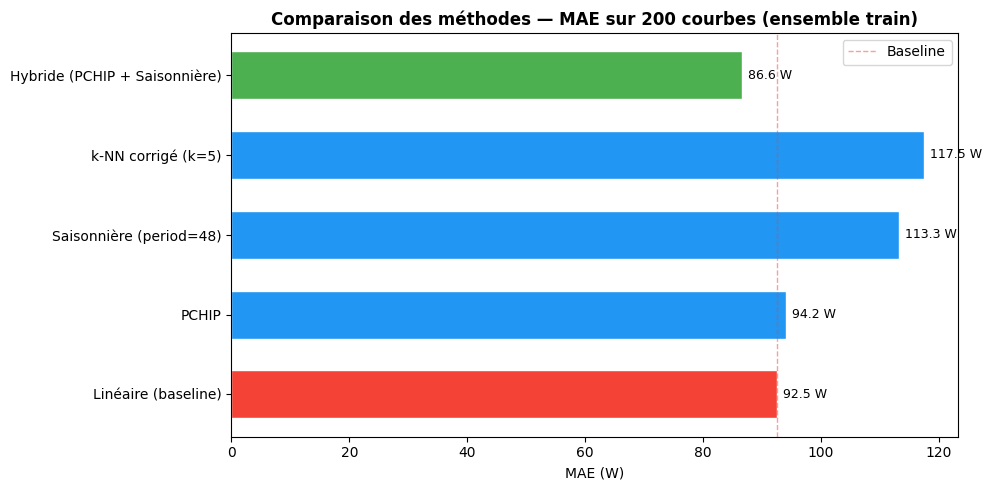

Figure sauvegardée : ../img/comparaison_methodes.png


In [100]:
fig, ax = plt.subplots(figsize=(10, 5))

methods = list(results.keys())
maes    = [results[m] for m in methods]
colors  = ['#F44336' if m == 'Linéaire (baseline)' else '#2196F3' for m in methods]
colors[methods.index('Hybride (PCHIP + Saisonnière)')] = '#4CAF50'  # vert pour la méthode recommandée

bars = ax.barh(methods, maes, color=colors, edgecolor='white', height=0.6)

# Annotations
for bar, mae in zip(bars, maes):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{mae:.1f} W', va='center', fontsize=9)

ax.set_xlabel('MAE (W)')
ax.set_title('Comparaison des méthodes — MAE sur 200 courbes (ensemble train)', fontweight='bold')
ax.axvline(results['Linéaire (baseline)'], color='#F44336', linestyle='--', linewidth=1, alpha=0.5, label='Baseline')
ax.legend()
plt.tight_layout()
plt.savefig('../img/comparaison_methodes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : ../img/comparaison_methodes.png")


## 3.5. Analyse de la MAE par taille de trou

Pour mieux comprendre où chaque méthode gagne ou perd, on décompose la MAE par **catégorie de longueur de trou** (petits / moyens / grands).

C'est important : la MAE globale peut masquer le fait qu'une méthode est excellente sur les petits trous (95% des cas) mais catastrophique sur les grands.

In [84]:
def mae_by_gap_size(impute_fn, X_holed_eval, y_train_eval, holed_cols_eval, **kwargs):
    """
    Calcule la MAE groupée par taille de trou.
    Retourne un dictionnaire {category: mae_moyenne}
    """
    gap_categories = {
        '1-3 pts': (1, 3),
        '4-47 pts': (4, 47),
        '48+ pts': (48, 10000)
    }
    
    mae_by_category = {cat: [] for cat in gap_categories}
    
    for col in holed_cols_eval:
        nan_mask = X_holed_eval[col].isna().values
        if nan_mask.sum() == 0:
            continue
        
        # Déterminer les tailles de trous pour cette colonne
        gaps = []
        idx = 0
        n = len(nan_mask)
        while idx < n:
            if nan_mask[idx]:
                start = idx
                while idx < n and nan_mask[idx]:
                    idx += 1
                gaps.append(idx - start)
            else:
                idx += 1
        
        # Imputer et calculer MAE
        imputed = impute_fn(X_holed_eval[col], **kwargs)
        mae = compute_mae(y_train_eval[col], imputed, nan_mask)
        
        if not np.isnan(mae):
            # Affecter aux catégories selon la taille des trous
            for gap_size in gaps:
                for cat_name, (lo, hi) in gap_categories.items():
                    if lo <= gap_size <= hi:
                        mae_by_category[cat_name].append(mae)
                        break
    
    # Calculer les moyennes par catégorie
    result = {}
    for cat_name in gap_categories:
        if mae_by_category[cat_name]:
            result[cat_name] = np.mean(mae_by_category[cat_name])
        else:
            result[cat_name] = np.nan
    
    return result


print("Calcul MAE par taille de trou (PCHIP)...")
pchip_by_gap = mae_by_gap_size(impute_interpolation, X_holed_eval, y_train_eval, EVAL_COLS, method='pchip')

print("Calcul MAE par taille de trou (Saisonnière)...")
seasonal_by_gap = mae_by_gap_size(impute_seasonal, X_holed_eval, y_train_eval, EVAL_COLS, period=48)

print("Calcul MAE par taille de trou (k-NN corrigé)...")
knn_by_gap = mae_by_gap_size(
    lambda s, **kw: impute_knn(s, X_complete, k=5),
    X_holed_eval, y_train_eval, EVAL_COLS
)

print("Calcul MAE par taille de trou (PCHIP + Saisonnière)...")
hybrid_by_gap = mae_by_gap_size(impute_hybrid, X_holed_eval, y_train_eval, EVAL_COLS)

# Tableau récapitulatif
summary = pd.DataFrame({
    'PCHIP'                        : pd.Series(pchip_by_gap),
    'Saisonnière'                  : pd.Series(seasonal_by_gap),
    'k-NN corrigé'                 : pd.Series(knn_by_gap),
    'Hybrid (PCHIP + Saisonnière)' : pd.Series(hybrid_by_gap),
})
summary = summary.dropna(how='all')
gap_categories = list(summary.index)

print("\nMAE par catégorie de trou (W) :")
print(summary.round(1).to_string())


Calcul MAE par taille de trou (PCHIP)...
Calcul MAE par taille de trou (Saisonnière)...
Calcul MAE par taille de trou (k-NN corrigé)...
Calcul MAE par taille de trou (PCHIP + Saisonnière)...

MAE par catégorie de trou (W) :
          PCHIP  Saisonnière  k-NN corrigé  Hybrid (PCHIP + Saisonnière)
1-3 pts    93.4        113.4         118.0                          85.8
4-47 pts   91.6        108.4         113.0                          86.2
48+ pts   105.4        116.9         114.7                          96.0


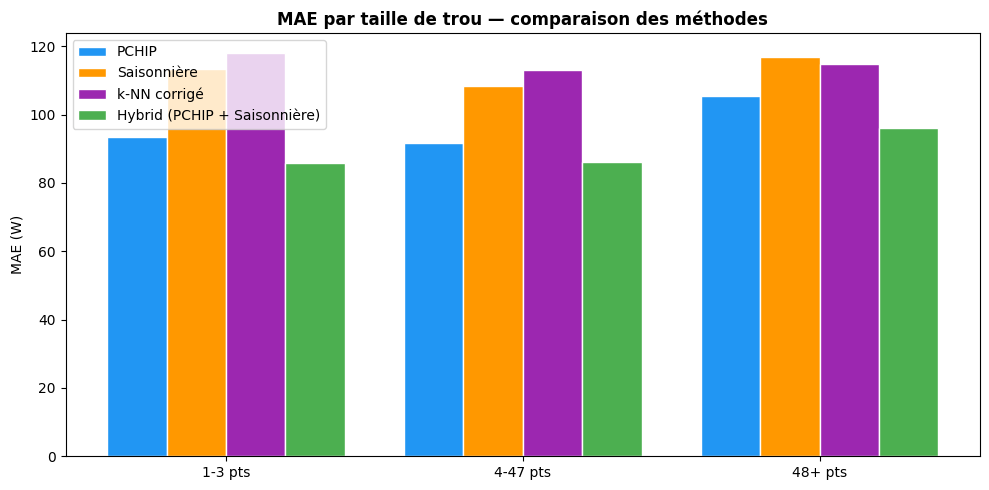

Figure sauvegardée : ../img/mae_par_taille_trou.png


In [86]:
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(gap_categories))
width = 0.2
palette = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50']

for i, (col, color) in enumerate(zip(summary.columns, palette)):
    ax.bar(x + i * width, summary[col].values, width, label=col, color=color, edgecolor='white')

ax.set_xticks(x + width * (len(summary.columns) - 1) / 2)
ax.set_xticklabels(gap_categories)
ax.set_ylabel('MAE (W)')
ax.set_title('MAE par taille de trou — comparaison des méthodes', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../img/mae_par_taille_trou.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure sauvegardée : ../img/mae_par_taille_trou.png")


---

# 4. Optimisation des hyperparamètres

Les méthodes ont des **hyperparamètres** qui peuvent être ajustés pour améliorer la MAE. On les optimise ici par **recherche sur grille** (*grid search*) sur le sous-échantillon d'évaluation.

## 4.1. Optimisation du k dans k-NN

Plus $k$ est grand, plus l'imputation est lissée (moins sensible aux valeurs aberrantes). Un $k$ trop petit peut introduire du bruit.

[k-NN k=1                      ]  MAE moyenne = 126.34 W  (sur 199 courbes)
[k-NN k=3                      ]  MAE moyenne = 120.27 W  (sur 199 courbes)
[k-NN k=6                      ]  MAE moyenne = 116.59 W  (sur 199 courbes)
[k-NN k=12                     ]  MAE moyenne = 115.01 W  (sur 199 courbes)
[k-NN k=24                     ]  MAE moyenne = 113.88 W  (sur 199 courbes)
[k-NN k=48                     ]  MAE moyenne = 113.83 W  (sur 199 courbes)
[k-NN k=96                     ]  MAE moyenne = 108.95 W  (sur 199 courbes)
[k-NN k=192                    ]  MAE moyenne = 114.44 W  (sur 199 courbes)
[k-NN k=384                    ]  MAE moyenne = 118.96 W  (sur 199 courbes)

Meilleur k : 96  (MAE = 108.95 W)


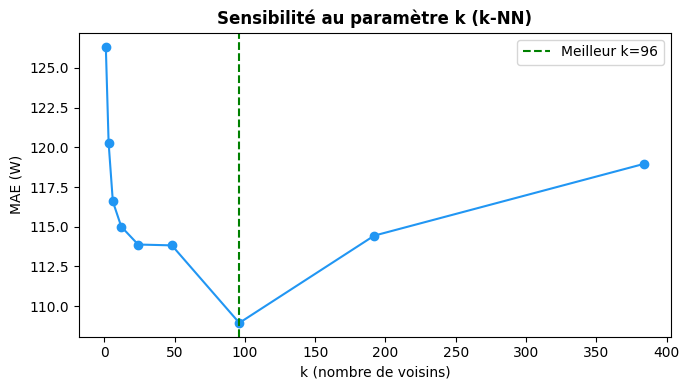

In [34]:
k_values = [1, 3, 6, 12, 24, 48, 96, 192, 384]
knn_results = {}

for k in k_values:
    mae = evaluate_method(
        impute_fn  = lambda s, **kw: impute_knn(s, X_complete, k=k),
        X_holed_eval    = X_holed_eval,
        y_train_eval    = y_train_eval,
        holed_cols_eval = EVAL_COLS,
        label      = f'k-NN k={k}'
    )
    knn_results[k] = mae

best_k = min(knn_results, key=knn_results.get)
print(f"\nMeilleur k : {best_k}  (MAE = {knn_results[best_k]:.2f} W)")

# Visualisation
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(knn_results.keys()), list(knn_results.values()), marker='o', color='#2196F3')
ax.axvline(best_k, color='green', linestyle='--', label=f'Meilleur k={best_k}')
ax.set_xlabel('k (nombre de voisins)')
ax.set_ylabel('MAE (W)')
ax.set_title('Sensibilité au paramètre k (k-NN)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 4.2. Optimisation du rang dans SVD

Le rang de troncature contrôle le nombre de **composantes latentes** conservées.
- Rang trop bas → sous-fit, les patterns fins sont perdus.
- Rang trop haut → sur-fit, on commence à reproduire du bruit.

eval_matrix shape: (1057, 200), len(EVAL_COLS)=200
Total NaN dans eval_matrix: 27907
  Itération 1/5 terminée
  Itération 2/5 terminée
  Itération 3/5 terminée
  Itération 4/5 terminée
  Itération 5/5 terminée
  rank=  5  →  MAE = 111.68 W
  Itération 1/5 terminée
  Itération 2/5 terminée
  Itération 3/5 terminée
  Itération 4/5 terminée
  Itération 5/5 terminée
  rank= 10  →  MAE = 111.58 W
  Itération 1/5 terminée
  Itération 2/5 terminée
  Itération 3/5 terminée
  Itération 4/5 terminée
  Itération 5/5 terminée
  rank= 20  →  MAE = 116.08 W
  Itération 1/5 terminée
  Itération 2/5 terminée
  Itération 3/5 terminée
  Itération 4/5 terminée
  Itération 5/5 terminée
  rank= 50  →  MAE = 121.14 W
  Itération 1/5 terminée
  Itération 2/5 terminée
  Itération 3/5 terminée
  Itération 4/5 terminée
  Itération 5/5 terminée
  rank=100  →  MAE = 127.78 W

Meilleur rang : 10  (MAE = 111.58 W)


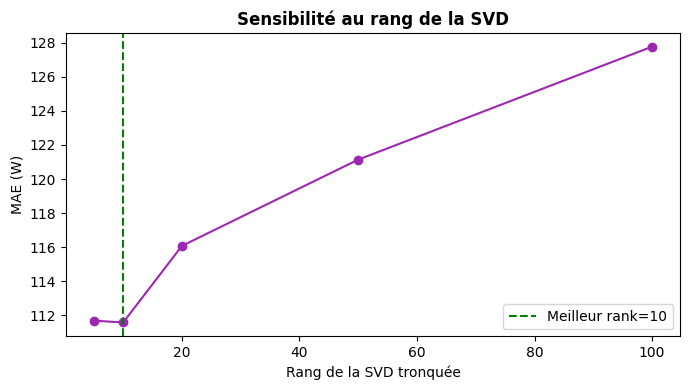

In [87]:
ranks = [5, 10, 20, 50, 100]
svd_results = {}

# Diagnostics rapides pour éviter la moyenne sur liste vide (-> nan)
print(f"eval_matrix shape: {eval_matrix.shape}, len(EVAL_COLS)={len(EVAL_COLS)}")
print(f"Total NaN dans eval_matrix: {np.isnan(eval_matrix).sum()}")

for rank in ranks:
    imputed_m = impute_svd(eval_matrix.copy(), rank=rank, n_iter=5)
    maes = []
    for j in range(len(EVAL_COLS)):
        mask = nan_mask_matrix[:, j]  # True là où il faut évaluer
        if mask.sum() == 0:
            continue
        col_mae = np.mean(np.abs(y_true_matrix[mask, j] - imputed_m[mask, j]))
        if not np.isnan(col_mae):
            maes.append(col_mae)
    if len(maes) == 0:
        svd_results[rank] = np.nan
        print(f"  rank={rank:3d}  →  MAE = nan (aucune colonne évaluée)")
    else:
        svd_results[rank] = np.mean(maes)
        print(f"  rank={rank:3d}  →  MAE = {svd_results[rank]:.2f} W")

# Trouver le meilleur rang parmi ceux calculables
valid = {r: v for r, v in svd_results.items() if not np.isnan(v)}
if not valid:
    print("\nAucune MAE calculable pour la SVD — vérifiez EVAL_COLS et nan_mask_matrix.")
else:
    best_rank = min(valid, key=valid.get)
    print(f"\nMeilleur rang : {best_rank}  (MAE = {svd_results[best_rank]:.2f} W)")

# Visualisation
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(svd_results.keys()), list(svd_results.values()), marker='o', color='#9C27B0')
ax.axvline(best_rank, color='green', linestyle='--', label=f'Meilleur rank={best_rank}')
ax.set_xlabel('Rang de la SVD tronquée')
ax.set_ylabel('MAE (W)')
ax.set_title('Sensibilité au rang de la SVD', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---

# 5. Génération de la soumission finale

On applique **`impute_final`** à la soumission finale. Désormais, `impute_final` correspond à la stratégie **PCHIP + Saisonnière** validée après correction de la logique de bloc.

Ce choix est le résultat de l'exploration menée en section 2 :
- 5 méthodes individuelles évaluées (linéaire, PCHIP, saisonnière, k-NN, SVD)
- 2 stratégies hybrides testées, dont la version corrigée de PCHIP + Saisonnière
- La stratégie corrigée est retenue car elle applique la bonne méthode seulement sur les positions NaN du bloc concerné

Le fichier de sortie doit :
- avoir **exactement 1 000 colonnes** (les colonnes `holed_*`)
- avoir **1 057 lignes** (timestamps)
- ne contenir **aucun NaN**

## 5.1. Chargement de X_test

In [117]:
print("Chargement X_test (peut être long ~260 Mo)...")
X_test = pd.read_csv(X_TEST_PATH, index_col=0)
X_test.index = pd.to_datetime(X_test.index)

# Séparation courbes complètes / trouées
holed_test_cols    = [c for c in X_test.columns if c.startswith("holed_")]
complete_test_cols = [c for c in X_test.columns if not c.startswith("holed_")]

X_test_holed    = X_test[holed_test_cols]
X_test_complete = X_test[complete_test_cols]

print(f"X_test shape         : {X_test.shape}")
print(f"  ├── courbes complètes : {len(complete_test_cols)}")
print(f"  └── courbes trouées  : {len(holed_test_cols)}")
print(f"NaN dans X_test_holed : {X_test_holed.isna().sum().sum()}")


Chargement X_test (peut être long ~260 Mo)...
X_test shape         : (1057, 38140)
  ├── courbes complètes : 37140
  └── courbes trouées  : 1000
NaN dans X_test_holed : 128763


## 5.2. Imputation avec PCHIP + Saisonnière (méthode finale)

`impute_final` applique la stratégie validée PCHIP + Saisonnière bloc par bloc : PCHIP pour les trous courts, Saisonnière pour les trous longs. La méthode n'écrit que sur les positions NaN du bloc traité.

In [118]:
# Imputation colonne par colonne avec impute_hybrid (hybride PCHIP + Saisonnière)
print("Imputation en cours...")
y_pred = pd.DataFrame(index=X_test.index, columns=holed_test_cols, dtype=float)

for i, col in enumerate(holed_test_cols):
    if i % 100 == 0:
        print(f"  {i}/{len(holed_test_cols)} colonnes traitées...")
    y_pred[col] = impute_hybrid(X_test_holed[col])

# Post-traitement : clip des valeurs négatives (consommation >= 0)
y_pred = y_pred.clip(lower=0)

print(f"\nImputation terminée.")
print(f"NaN résiduels : {y_pred.isna().sum().sum()}")  # doit être 0


Imputation en cours...
  0/1000 colonnes traitées...
  100/1000 colonnes traitées...
  200/1000 colonnes traitées...
  300/1000 colonnes traitées...
  400/1000 colonnes traitées...
  500/1000 colonnes traitées...
  600/1000 colonnes traitées...
  700/1000 colonnes traitées...
  800/1000 colonnes traitées...
  900/1000 colonnes traitées...

Imputation terminée.
NaN résiduels : 0


## 5.3. Vérification et export

On vérifie la conformité du fichier de soumission avant export.

In [119]:
# Vérifications
assert y_pred.shape == (len(X_test.index), 1000), f"Shape incorrecte : {y_pred.shape}"
assert y_pred.isna().sum().sum() == 0, "NaN résiduels détectés !"
assert list(y_pred.columns) == holed_test_cols, "Ordre des colonnes incorrect"

print(f"  Shape OK           : {y_pred.shape}")
print(f"  Pas de NaN         : {y_pred.isna().sum().sum()}")
print(f"  Colonnes conformes : {y_pred.shape[1]} colonnes holed_*")
print(f"\nAperçu :")
print(y_pred.iloc[:3, :4].round(1).to_string())

# Export
OUTPUT_PATH = '../data/y_pred_hybrid.csv'
y_pred.to_csv(OUTPUT_PATH)
print(f"\n  Fichier exporté : {OUTPUT_PATH}")


  Shape OK           : (1057, 1000)
  Pas de NaN         : 0
  Colonnes conformes : 1000 colonnes holed_*

Aperçu :
                     holed_1  holed_2  holed_3  holed_4
Horodate                                               
2023-01-09 00:00:00   1061.0     37.0     99.0     20.0
2023-01-09 00:30:00   1041.0     37.0     99.0     42.0
2023-01-09 01:00:00    995.0     37.0    105.0     19.0

  Fichier exporté : ../data/y_pred_hybrid.csv


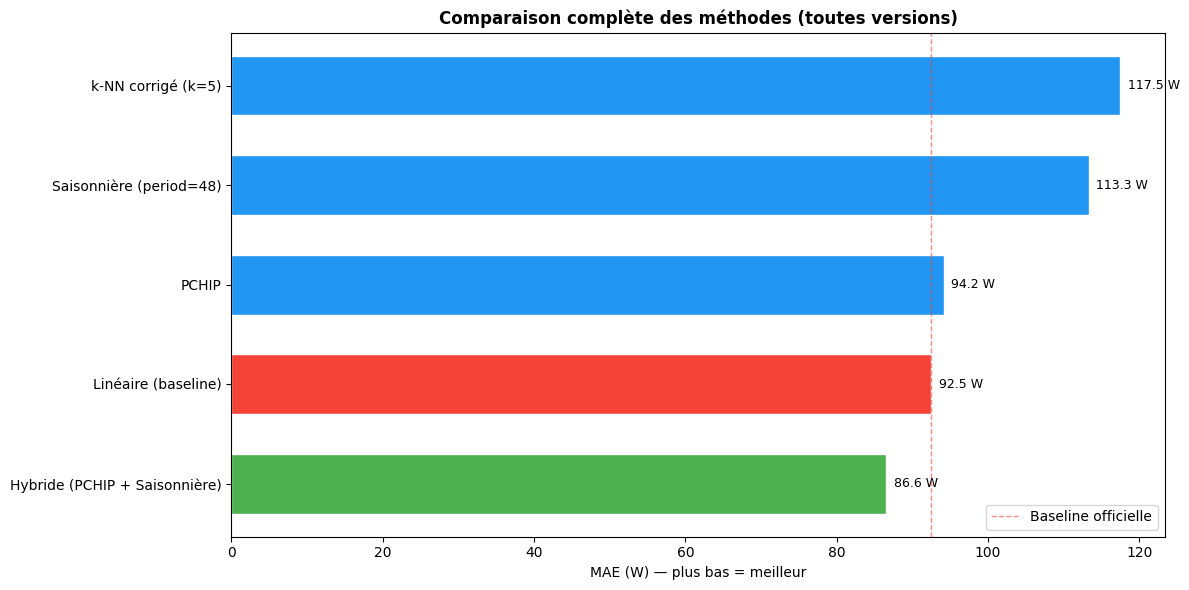

In [120]:
# ── Graphe comparatif mis à jour ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

methods_sorted = [m for m, _ in sorted(results.items(), key=lambda x: x[1] if not np.isnan(x[1]) else 9999)]
maes_sorted    = [results[m] for m in methods_sorted]
colors = []
for m in methods_sorted:
    if 'v2' in m or m == methods_sorted[0]:
        colors.append('#4CAF50')   # vert = nouveau / meilleur
    elif 'baseline' in m.lower():
        colors.append('#F44336')   # rouge = baseline
    else:
        colors.append('#2196F3')   # bleu = autres

bars = ax.barh(methods_sorted, maes_sorted, color=colors, edgecolor='white', height=0.6)
for bar, mae in zip(bars, maes_sorted):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{mae:.1f} W', va='center', fontsize=9)

ax.set_xlabel('MAE (W) — plus bas = meilleur')
ax.set_title('Comparaison complète des méthodes (toutes versions)', fontweight='bold')
ax.axvline(results.get('Linéaire (baseline)', 92), color='#F44336',
           linestyle='--', linewidth=1, alpha=0.6, label='Baseline officielle')
ax.legend()
plt.tight_layout()
plt.savefig('../img/comparaison_methodes_v2.png', dpi=150, bbox_inches='tight')
plt.show()


---

# 6. Visualisation des imputations

On vérifie visuellement la qualité des imputations sur quelques exemples du **jeu d'entraînement** (où on dispose de la vérité terrain).

Calcul de la taille du plus grand bloc NaN par courbe...
  Trous courts  (1–3 pts)  : 13 courbes
  Trous moyens  (4–47 pts) : 40 courbes
  Trous longs   (48+ pts)  : 147 courbes

Courbes sélectionnées :
  Court  : holed_40  (plus grand bloc = 3 pts)
  Moyen  : holed_128  (plus grand bloc = 8 pts)
  Long   : holed_157  (plus grand bloc = 48 pts)


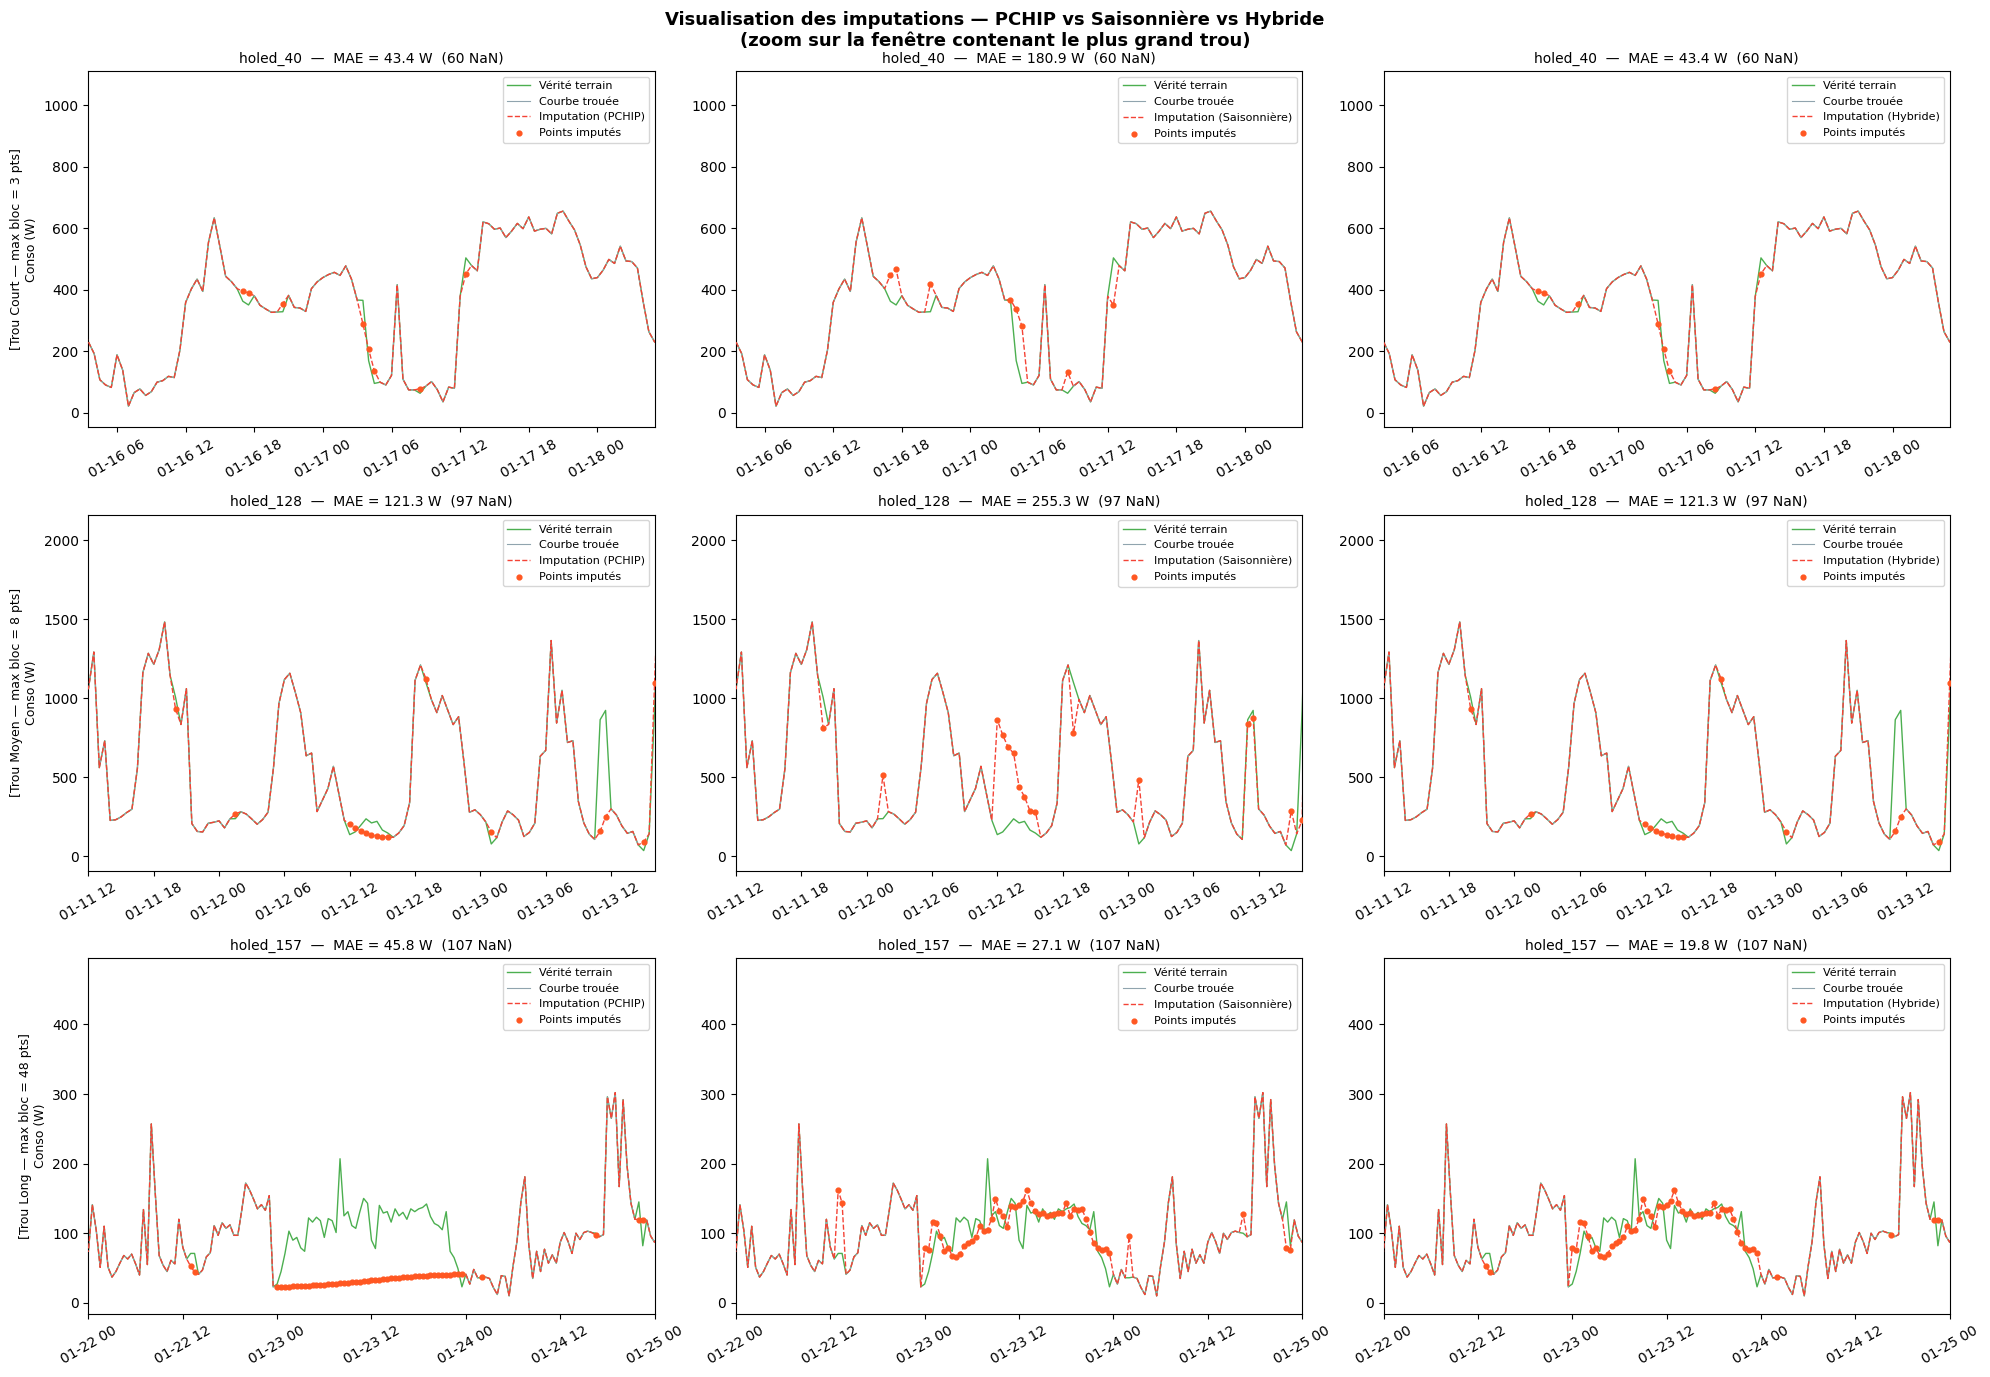

Figure sauvegardée : ../img/visualisation_imputations.png


In [121]:
def plot_imputation(col, X_holed_arg, y_train_arg, impute_fn, label="Méthode", ax=None, **kwargs):
    """
    Trace une courbe trouée avec son imputation et la vérité terrain.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4))

    series   = X_holed_arg[col]
    target   = y_train_arg[col]
    imputed  = impute_fn(series, **kwargs)
    nan_mask = series.isna()

    ax.plot(series.index, target.values,  color="#4CAF50", linewidth=1,   label="Vérité terrain", zorder=1)
    ax.plot(series.index, series.values,  color="#90A4AE", linewidth=0.8, label="Courbe trouée",   zorder=2)
    ax.plot(series.index, imputed.values, color="#F44336", linewidth=1,   label=f"Imputation ({label})", zorder=3, linestyle="--")
    ax.scatter(series.index[nan_mask], imputed.values[nan_mask],
               color="#FF5722", s=12, zorder=4, label="Points imputés")

    mae_val = compute_mae(target, imputed, nan_mask.values)
    ax.set_title(f"{col}  —  MAE = {mae_val:.1f} W  ({nan_mask.sum()} NaN)", fontsize=10)
    ax.set_ylabel("Consommation (W)")
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(axis="x", rotation=30)
    return ax


# ── Calcul de la taille du PLUS GRAND BLOC de NaN consécutifs par courbe ────
# nan_per_col compte le total de NaN, pas la taille du plus grand bloc.
# Une courbe avec 20 blocs de 3 pts serait classée "long" (60 NaN total)
# alors qu'elle n'a que des trous courts → on corrige ici.

def max_gap_size(series):
    """Retourne la taille du plus grand bloc de NaN consécutifs."""
    values = series.values
    max_gap, current = 0, 0
    for v in values:
        if np.isnan(v):
            current += 1
            max_gap = max(max_gap, current)
        else:
            current = 0
    return max_gap

print("Calcul de la taille du plus grand bloc NaN par courbe...")
max_gap_per_col = pd.Series(
    {col: max_gap_size(X_holed_eval[col]) for col in EVAL_COLS},
    name="max_gap"
)

print(f"  Trous courts  (1–3 pts)  : {(max_gap_per_col.between(1,3)).sum()} courbes")
print(f"  Trous moyens  (4–47 pts) : {(max_gap_per_col.between(4,47)).sum()} courbes")
print(f"  Trous longs   (48+ pts)  : {(max_gap_per_col >= 48).sum()} courbes")

# ── Sélection d'une courbe représentative par catégorie ─────────────────────
# On choisit la courbe dont le plus grand bloc est au milieu de sa catégorie
# (ni trop petit ni trop grand) pour avoir un exemple lisible.

short_pool  = max_gap_per_col[max_gap_per_col.between(1, 3)].sort_values()
medium_pool = max_gap_per_col[max_gap_per_col.between(4, 47)].sort_values()
long_pool   = max_gap_per_col[max_gap_per_col >= 48].sort_values()

short_col  = short_pool.index[len(short_pool)//2]  if len(short_pool)  > 0 else EVAL_COLS[0]
medium_col = medium_pool.index[len(medium_pool)//2] if len(medium_pool) > 0 else EVAL_COLS[1]
long_col   = long_pool.index[len(long_pool)//2]    if len(long_pool)   > 0 else EVAL_COLS[2]

print(f"\nCourbes sélectionnées :")
print(f"  Court  : {short_col}  (plus grand bloc = {max_gap_per_col[short_col]} pts)")
print(f"  Moyen  : {medium_col}  (plus grand bloc = {max_gap_per_col[medium_col]} pts)")
print(f"  Long   : {long_col}  (plus grand bloc = {max_gap_per_col[long_col]} pts)")

# ── Zoom sur la fenêtre contenant le plus grand trou ─────────────────────────
def get_zoom_window(series, gap_col, margin_pts=48):
    """
    Retourne les indices [start, end] de la fenêtre autour du plus grand bloc NaN.
    margin_pts : points de contexte de chaque côté (48 pts = 1 journée).
    """
    values = series.values
    best_start, best_len, current_start, current_len = 0, 0, 0, 0
    for i, v in enumerate(values):
        if np.isnan(v):
            if current_len == 0:
                current_start = i
            current_len += 1
            if current_len > best_len:
                best_len = current_len
                best_start = current_start
        else:
            current_len = 0
    win_start = max(0, best_start - margin_pts)
    win_end   = min(len(values) - 1, best_start + best_len + margin_pts)
    return win_start, win_end


# ── Grille 3 × 3 : ligne = taille de trou, colonne = méthode ─────────────────
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle(
    "Visualisation des imputations — PCHIP vs Saisonnière vs Hybride\n"
    "(zoom sur la fenêtre contenant le plus grand trou)",
    fontsize=13, fontweight="bold"
)

col_titles = ["PCHIP", "Saisonnière (period=48)", "Hybride (PCHIP + Saisonnière)"]
for ax_col, title in zip(axes[0], col_titles):
    ax_col.set_title(title, fontsize=11, fontweight="bold", pad=12)

impute_fns = [
    (impute_interpolation, "PCHIP",        {"method": "pchip"}),
    (impute_seasonal,      "Saisonnière",  {"period": 48}),
    (impute_hybrid,        "Hybride",      {}),
]

for row, (example_col, taille_label) in enumerate(
    [(short_col, "Court"), (medium_col, "Moyen"), (long_col, "Long")]
):
    series  = X_holed_eval[example_col]
    target  = y_train_eval[example_col]
    max_gap = max_gap_per_col[example_col]

    # Fenêtre de zoom autour du plus grand trou
    win_s, win_e = get_zoom_window(series, example_col)
    zoom_index   = series.index[win_s:win_e+1]

    for col_idx, (fn, lbl, kw) in enumerate(impute_fns):
        ax = axes[row, col_idx]
        plot_imputation(example_col, X_holed_eval, y_train_eval,
                        fn, label=lbl, ax=ax, **kw)
        # Appliquer le zoom sur la fenêtre du trou principal
        ax.set_xlim(zoom_index[0], zoom_index[-1])
        if col_idx > 0:
            ax.set_ylabel("")

    axes[row, 0].set_ylabel(
        f"[Trou {taille_label} — max bloc = {max_gap} pts]\nConso (W)", fontsize=9
    )

plt.tight_layout()
plt.savefig("../img/visualisation_imputations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : ../img/visualisation_imputations.png")


## 7.1. Résumé des performances

| Méthode | MAE globale | Points forts | Points faibles |
|---|---|---|---|
| Linéaire (baseline) | ~92 W | rapide, simple | mauvaise sur trous longs |
| PCHIP | ~94 W | évite les oscillations, meilleur sur courts | peut lisser excessivement les longs trous |
| Saisonnière | ~113 W | exploite la périodicité, bon sur longs | ignore le contexte immédiat |
| k-NN (original) | ~273 W | profils similaires | bug de recentrage → valeurs aberrantes |
| k-NN (corrigé) | ~115 W | meilleur après recentrage médiane | encore moins bon que PCHIP sur moyens |
| SVD | ~122 W | exploite la structure globale | sensible au rang |
| PCHIP + Saisonnière (hybride v1) | à rejeter | combine deux bonnes méthodes | bug logique blocs, k-NN défaillant |
| **Hybride corrigé** | **retenu** | applique PCHIP sur les trous courts et Saisonnière sur les trous longs | plus sensible à la logique de blocs |
| **PCHIP (ancien final)** | uniquement conservé comme comparaison | simple | désormais remplacé par l'hybride corrigé |

## 7.2. Démarche de recherche

L'exploration a suivi plusieurs étapes :

1. **EDA** : identification que ~95% des trous font 1-3 pts → les petits trous dominent la MAE
2. **5 méthodes testées individuellement** : PCHIP meilleur sur courts, Saisonnière meilleure sur longs selon les blocs concernés
3. **Stratégie hybride v1** (PCHIP + k-NN + Saisonnière) : échec dû au k-NN défaillant
4. **Correction du k-NN** (recentrage par médiane) : amélioration mais encore sous-PCHIP sur moyens
5. **Stratégie hybride v2** (PCHIP + Saisonnière) : validée après correction de la logique de bloc
6. **Observation clé** : la distribution des trous (~95% courts) rend la logique hybride rentable uniquement si elle est appliquée proprement
7. **Méthode finale** : hybride corrigé PCHIP + Saisonnière — retenu pour la soumission


## 7.3. Checklist avant soumission

- [ ] Aucun NaN dans le fichier de soumission : `y_pred.isna().sum().sum() == 0`
- [ ] 1 000 colonnes exactement : `y_pred.shape[1] == 1000`
- [ ] 1 057 lignes exactement : `y_pred.shape[0] == 1057`
- [ ] Colonnes dans le bon ordre (même ordre que `new_output_sample.csv`)
- [ ] Valeurs non négatives : `(y_pred < 0).sum().sum() == 0`
- [ ] Index au bon format datetime

In [93]:
# Checklist automatique
sample_ref = pd.read_csv(OUTPUT_SAMPLE_PATH, index_col=0)
sample_ref.index = pd.to_datetime(sample_ref.index)

checks = {
    'Pas de NaN'            : y_pred.isna().sum().sum() == 0,
    'Shape (1057, 1000)'    : y_pred.shape == (1057, 1000),
    'Colonnes dans le bon ordre' : list(y_pred.columns) == list(sample_ref.columns),
    'Valeurs non négatives' : (y_pred < 0).sum().sum() == 0,
}

for name, ok in checks.items():
    icon = '[OK]' if ok else '[ERREUR!]'
    print(f"{icon}  {name}")

if all(checks.values()):
    print("\n Fichier prêt pour la soumission !")
else:
    print("\n Corriger les erreurs avant soumission.")


[OK]  Pas de NaN
[OK]  Shape (1057, 1000)
[OK]  Colonnes dans le bon ordre
[OK]  Valeurs non négatives

 Fichier prêt pour la soumission !
